# Fire Intensity Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
data = pd.read_csv('fire_archive_J1V-C2_726206.csv')


In [3]:
data.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,70.94708,74.53897,331.97,0.54,0.51,2024-02-01,7,N20,VIIRS,n,2,246.54,3.93,N,0
1,68.41541,83.62364,367.00,0.50,0.66,2024-02-01,7,N20,VIIRS,h,2,249.76,7.27,N,2
2,66.66642,80.44739,367.00,0.59,0.70,2024-02-01,7,N20,VIIRS,h,2,249.78,13.21,N,2
3,70.99835,73.84378,345.58,0.53,0.50,2024-02-01,7,N20,VIIRS,n,2,252.52,23.67,N,0
4,67.28266,83.03193,329.51,0.58,0.70,2024-02-01,7,N20,VIIRS,n,2,251.59,3.59,N,2


FRP distribution

FRP vs brightness

FRP vs bright_t31

Confidence vs FRP

Correlation heatmap


In [4]:
data['confidence'].isnull().sum()

np.int64(0)

## 1. frp distribution (Univariate analysis)

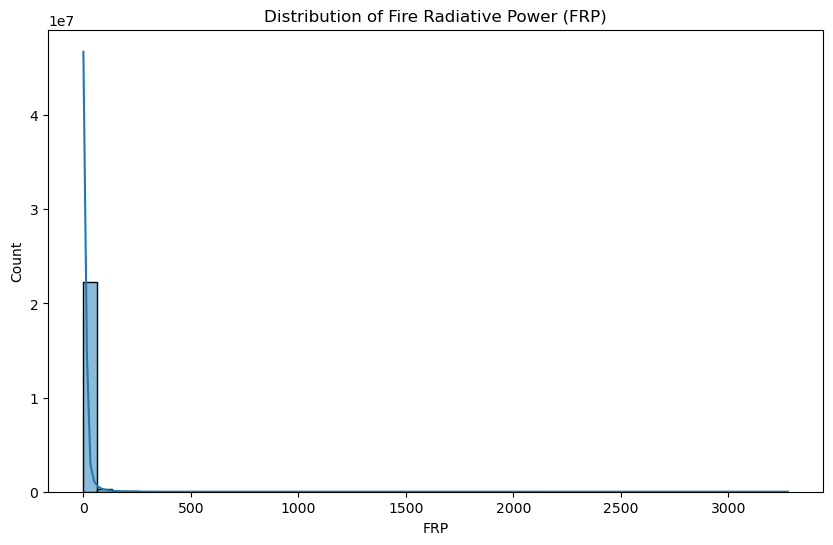

In [5]:
frp_df = data[["frp"]].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(data=frp_df, x="frp", bins=50, kde=True)
plt.title("Distribution of Fire Radiative Power (FRP)")
plt.xlabel("FRP")
plt.ylabel("Count")
plt.show()

### More readable version using log. Interesting because it shows normal distribution?

/opt/anaconda3/envs/data220/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


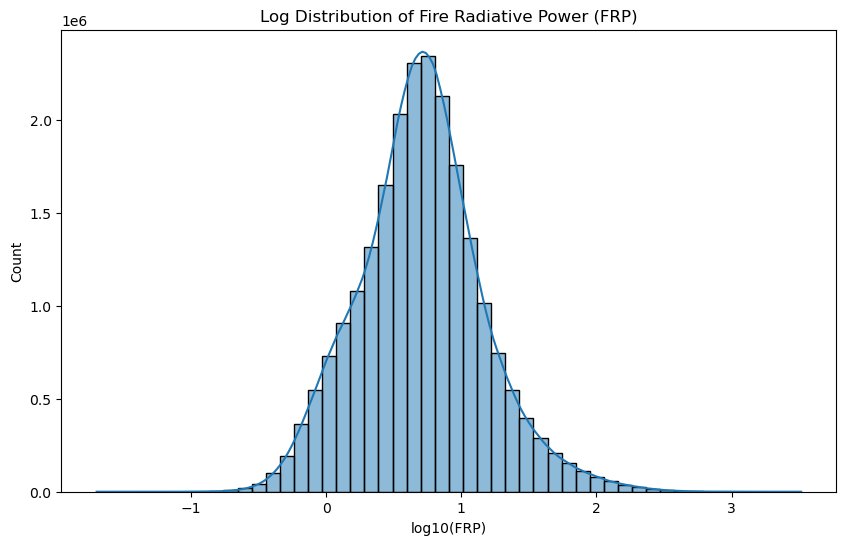

In [6]:
frp_df["log_frp"] = np.log10(frp_df["frp"])

plt.figure(figsize=(10, 6))
sns.histplot(data=frp_df, x="log_frp", bins=50, kde=True)
plt.title("Log Distribution of Fire Radiative Power (FRP)")
plt.xlabel("log10(FRP)")
plt.ylabel("Count")
plt.show()

## 2. frp vs Brightness

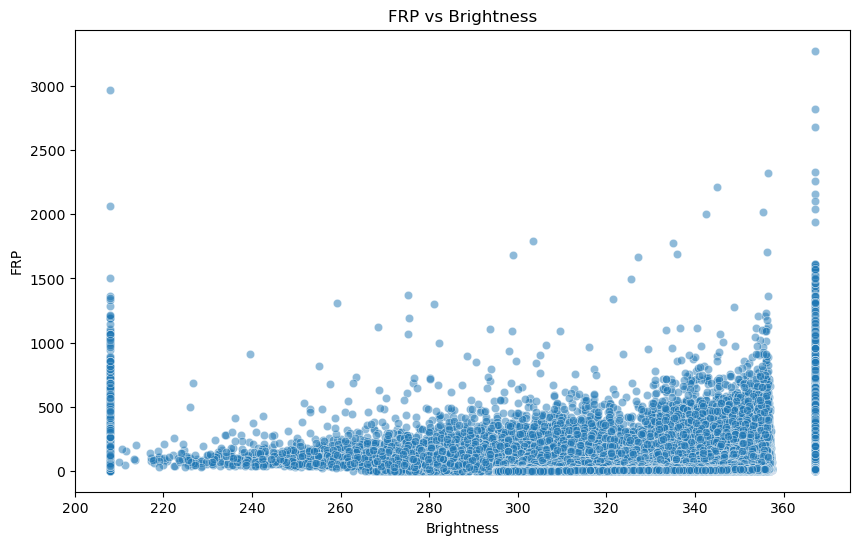

In [7]:
scatter_df = data[["frp", "brightness"]].dropna()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_df, x="brightness", y="frp", alpha=0.5)
plt.title("FRP vs Brightness")
plt.xlabel("Brightness")
plt.ylabel("FRP")
plt.show()

## 3. frp vs bright_t31

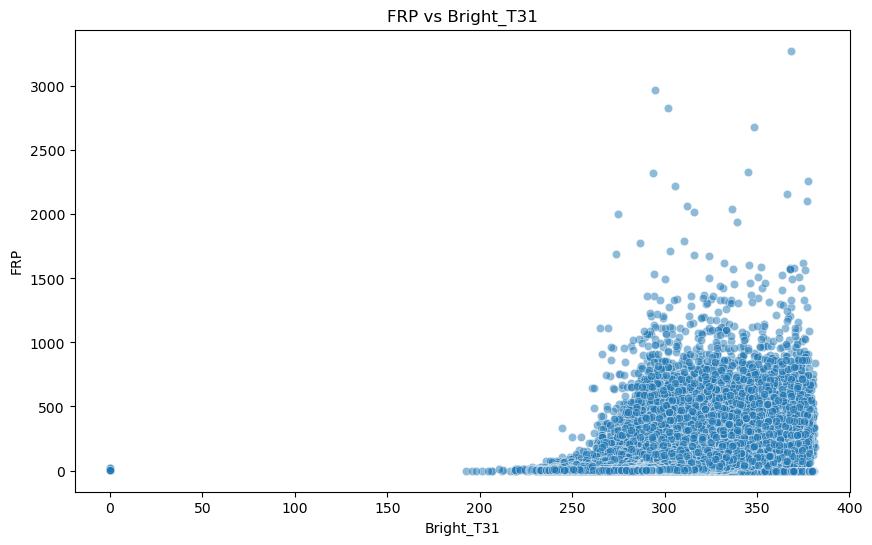

In [8]:
scatter_df = data[["frp", "bright_t31"]].dropna()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_df, x="bright_t31", y="frp", alpha=0.5)
plt.title("FRP vs Bright_T31")
plt.xlabel("Bright_T31")
plt.ylabel("FRP")
plt.show()

## confidence vs frp

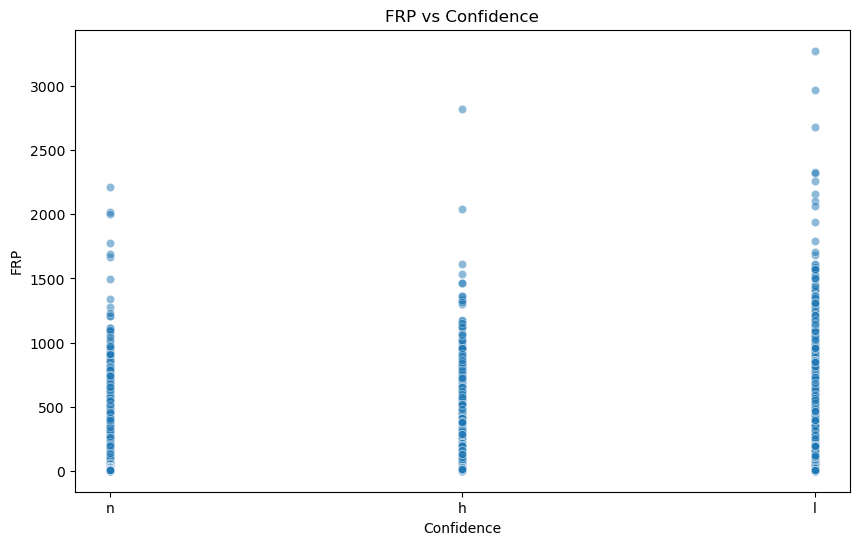

In [9]:
scatter_df = data[["frp", "confidence"]].dropna()
plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_df, x="confidence", y="frp", alpha=0.5)
plt.title("FRP vs Confidence")
plt.xlabel("Confidence")
plt.ylabel("FRP")
plt.show()

### Log scale again to understand this better

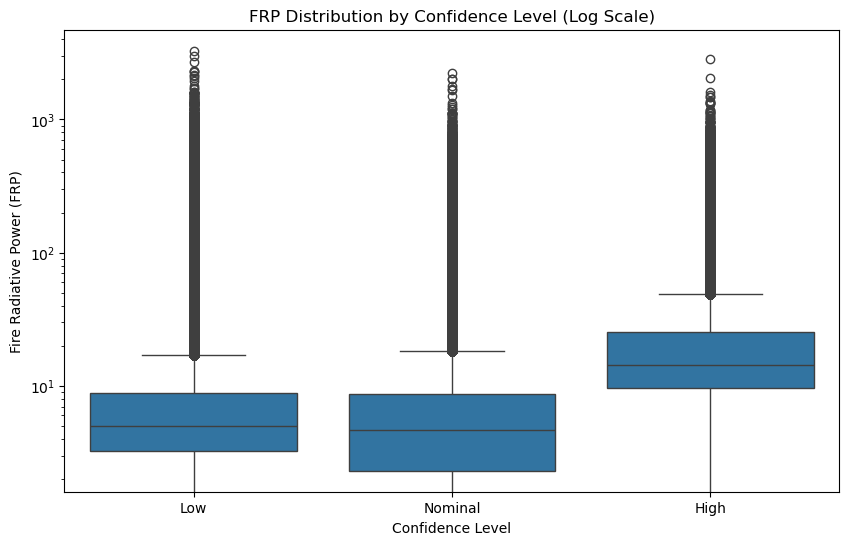

In [10]:
box_df = data[["frp","confidence"]].dropna().copy()

plt.figure(figsize=(10,6))

sns.boxplot(
    data=box_df,
    x="confidence",
    y="frp",
    order=["l","n","h"]
)

plt.yscale("log")

plt.title("FRP Distribution by Confidence Level (Log Scale)")
plt.xlabel("Confidence Level")
plt.ylabel("Fire Radiative Power (FRP)")

plt.xticks([0,1,2],["Low","Nominal","High"])

plt.show()

### 4. Correlation Heatmap 
Interesting point:
Confidence is more of a classification quality metric, not a direct measurement of fire intensity

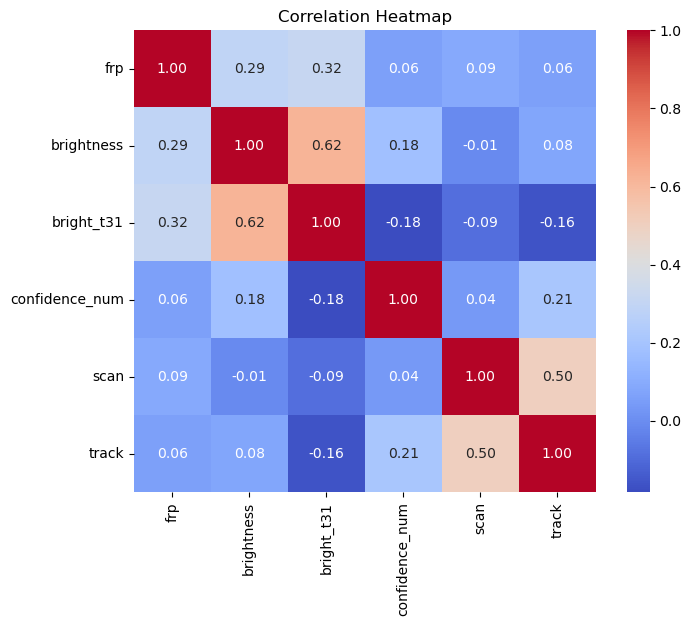

In [11]:
# Convert confidence to numeric if possible
confidence_map = {"l":1, "n":2, "h":3}
data["confidence_num"] = data["confidence"].map(confidence_map)

corr_matrix = data[["frp", "brightness", "bright_t31", "confidence_num", "scan", "track"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap")
plt.show()

### Using only the sensor features

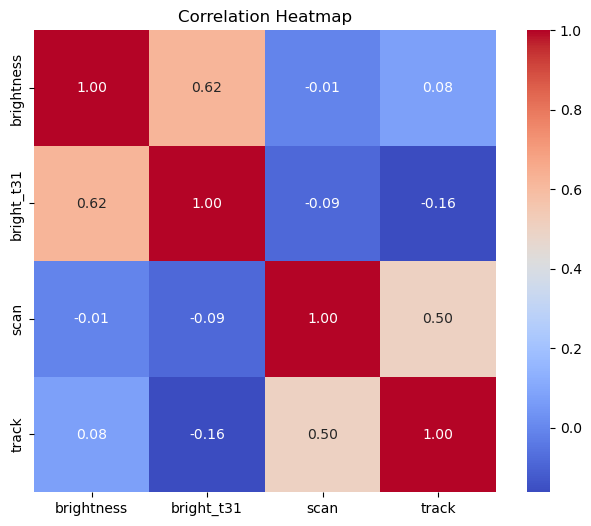

In [13]:
corr_matrix = data[["brightness", "bright_t31","scan", "track"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap")
plt.show()